### Loading data object

In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Microglia"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 81472 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color', 'batch'
    var: 'gene_symbol'

In [4]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col=0)
modules_df.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
ENSMUSG00000004296,ENSMUSG00000004296,MG-M1,turquoise,0.067324,-0.005248,0.069128,-0.008137,0.007815,-0.031117
ENSMUSG00000002985,ENSMUSG00000002985,MG-M1,turquoise,0.189944,0.147565,0.190743,0.233783,0.050853,-0.158240
ENSMUSG00000039109,ENSMUSG00000039109,grey,grey,0.001604,0.012000,0.142080,0.001089,0.063053,0.013650
ENSMUSG00000015568,ENSMUSG00000015568,MG-M2,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402
ENSMUSG00000020914,ENSMUSG00000020914,grey,grey,0.018736,-0.008138,0.052446,-0.005465,0.032833,0.016444


In [5]:
module_names = {
    "MG-M1": "Classical Inflammation",
    "MG-M2": "Phagocytosis & Antigen Display",
    "MG-M3": "ECM Remodeling",
    "MG-M4": "Interferon Response",
    "MG-M5": "Gliosis"
}

In [6]:
# Rename the 'module' column in modules_df using module_names and save as a new dataframe
modules_df_renamed = modules_df.copy()
modules_df_renamed["module"] = modules_df_renamed["module"].map(module_names).fillna(modules_df_renamed["module"])
modules_df_renamed.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
ENSMUSG00000004296,ENSMUSG00000004296,Classical Inflammation,turquoise,0.067324,-0.005248,0.069128,-0.008137,0.007815,-0.031117
ENSMUSG00000002985,ENSMUSG00000002985,Classical Inflammation,turquoise,0.189944,0.147565,0.190743,0.233783,0.050853,-0.158240
ENSMUSG00000039109,ENSMUSG00000039109,grey,grey,0.001604,0.012000,0.142080,0.001089,0.063053,0.013650
ENSMUSG00000015568,ENSMUSG00000015568,Phagocytosis & Antigen Display,brown,0.067394,0.009954,0.541998,-0.002288,0.017932,-0.027402
ENSMUSG00000020914,ENSMUSG00000020914,grey,grey,0.018736,-0.008138,0.052446,-0.005465,0.032833,0.016444


### GO

In [7]:
from gprofiler import GProfiler

module_gene_dict = modules_df_renamed.groupby("module")["gene_name"].apply(list).to_dict()

gp = GProfiler(return_dataframe=True)
all_results = []

for module, genes in module_gene_dict.items():
    if module == "grey":
        continue
    
    # gProfiler expects gene symbols or ENSEMBL IDs
    if len(genes) == 0:
        continue
    res = gp.profile(
        organism="mmusculus",
        query=genes,
        sources=['GO:BP'],
        user_threshold=0.05,
        significance_threshold_method='fdr'
    )
    if res.empty:
        continue
    res['module'] = module
    all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)

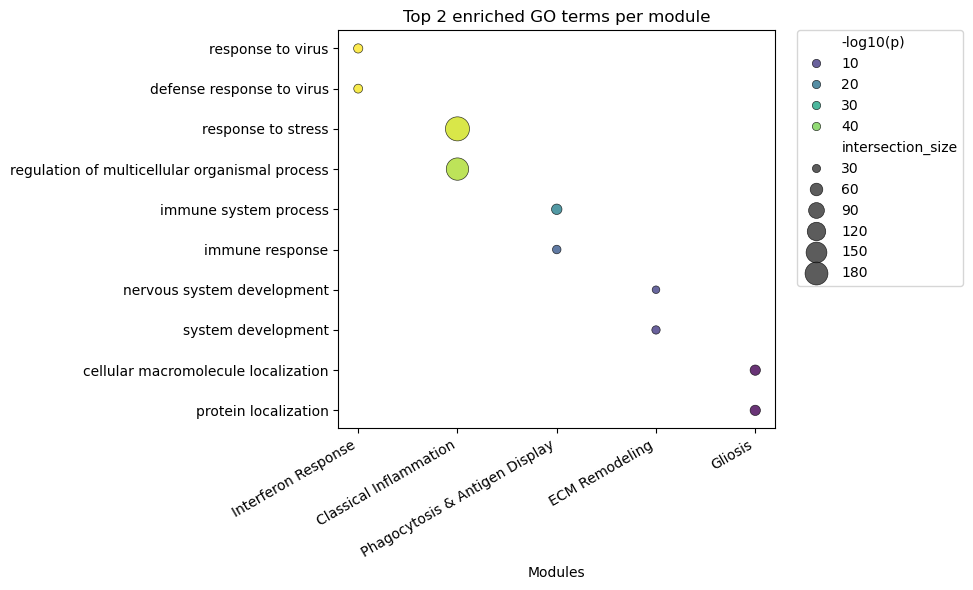

In [8]:
# ---------------------------------------------
# Parameters
# ---------------------------------------------
top_n = 2  # Top terms per cluster to include

# ---------------------------------------------
# Select top N enriched terms per cluster
# ---------------------------------------------
top_terms_df = (
    results_df
    .sort_values("p_value")
    .groupby("module")
    .head(top_n)
    .copy()
)

# Shorten term names for better plotting
top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

# Optional: sort GO terms by frequency of appearance across clusters
term_order = (
    top_terms_df["term_display"]
    .value_counts()
    .index.tolist()
)

# ---------------------------------------------
# Create the Dot Plot
# ---------------------------------------------
plt.figure(figsize=(10, max(6, 0.4 * len(term_order))))
sns.scatterplot(
    data=top_terms_df,
    x="module",
    y="term_display",
    size="intersection_size",
    hue="-log10(p)",
    sizes=(30, 300),
    palette="viridis",
    edgecolor="black",
    alpha=0.8,
)

# Improve layout
plt.xticks(rotation=30, ha="right")
plt.ylabel("")
plt.xlabel("Modules")
plt.title(f"Top {top_n} enriched GO terms per module")

# Legends
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.savefig("figures/go_dotplot_Microglia_CNA.svg")
plt.show()

### ME

In [7]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"processed/WMB-10Xv3-{select_region}-raw-wmeta-DEG-res0.50.h5ad"
adata_DEG = sc.read_h5ad(expr_path)
adata_DEG

AnnData object with n_obs × n_vars = 81472 × 2000
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color', 'batch', 'leiden_res_0.50'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res_0.50', 'log1p', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [8]:
from sklearn.decomposition import PCA

# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.scale(adata)  # Scale the data

# Get unique modules and their gene lists
module_gene_dict = modules_df_renamed.groupby("module")["gene_name"].apply(list).to_dict()

# Store eigengenes in a DataFrame
eigengenes = pd.DataFrame(index=adata.obs_names)

for module, genes in module_gene_dict.items():
    if module == "grey":
        continue

    # Filter genes present in adata
    genes_in_adata = [g for g in genes if g in adata.var_names]
    if len(genes_in_adata) < 2:
        continue  # Need at least 2 genes for PCA

    # Extract expression matrix for the module
    X = adata[:, genes_in_adata].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()  # Convert sparse to dense if needed

    # Compute first principal component (eigengene)
    pca = PCA(n_components=1)
    eigengene = pca.fit_transform(X).flatten()
    eigengenes[module] = eigengene

eigengenes.head()

,Classical Inflammation,ECM Remodeling,Gliosis,Interferon Response,Phagocytosis & Antigen Display
cell_label,,,,,
TGGATCAGTAACACCT-478_A02-0,1.806225,-0.435756,3.519673,-1.010356,-0.150218
TCACTCGCAAGTTCGT-215_C01-0,-8.417881,-1.139485,-0.486646,-0.214476,-0.303976
GAGTGAGTCCTTATCA-472_B05-0,11.013382,0.819943,-3.545289,-0.839389,1.247553
CACGGGTTCATTTCCA-216_D01-0,-7.477345,-1.964909,2.866273,-0.052706,0.651333
TTTCACATCCGCACTT-171_C01-0,2.424165,-2.455469,-1.317160,-0.502564,0.509258


### Dotplot

In [9]:
# Adding MEs to AnnData object
merged_df = pd.merge(adata.obs, eigengenes, left_index=True, right_index=True)
merged_df.head()

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,batch,Classical Inflammation,ECM Remodeling,Gliosis,Interferon Response,Phagocytosis & Antigen Display
cell_label,,,,,,,,,,,,,,,,,,,,,
TGGATCAGTAACACCT-478_A02-0,TGGATCAGTAACACCT,478_A02,L8TX_210107_02_H11,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-556943,Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,1.806225,-0.435756,3.519673,-1.010356,-0.150218
TCACTCGCAAGTTCGT-215_C01-0,TCACTCGCAAGTTCGT,215_C01,L8TX_200206_01_D03,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507771,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,-8.417881,-1.139485,-0.486646,-0.214476,-0.303976
GAGTGAGTCCTTATCA-472_B05-0,GAGTGAGTCCTTATCA,472_B05,L8TX_201217_01_H07,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-557213,Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,11.013382,0.819943,-3.545289,-0.839389,1.247553
CACGGGTTCATTTCCA-216_D01-0,CACGGGTTCATTTCCA,216_D01,L8TX_200206_01_A04,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507773,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,-7.477345,-1.964909,2.866273,-0.052706,0.651333
TTTCACATCCGCACTT-171_C01-0,TTTCACATCCGCACTT,171_C01,L8TX_191029_01_E08,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-493659,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#62CC3D,#651FCC,28,#CC0026,0,2.424165,-2.455469,-1.317160,-0.502564,0.509258


In [10]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(merged_df[eigengenes.columns])
adata_vis.obs["clusters"] = adata_DEG.obs["leiden_res_0.50"]  # Add cell type labels

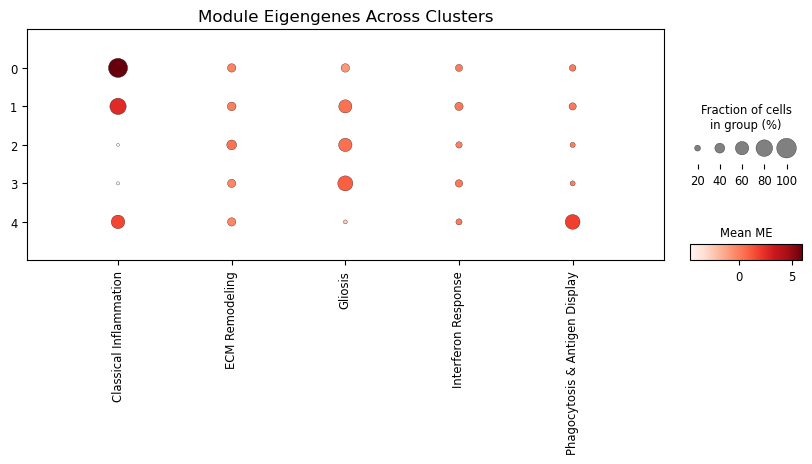

In [12]:
# Matrixplot
sc.pl.dotplot(
    adata_vis,
    var_names=eigengenes.columns,
    groupby="clusters",
    swap_axes=False,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 3),  # Adjust size as needed
    title="Module Eigengenes Across Clusters",
    colorbar_title="Mean ME",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
    save = "ABCA_MG_CNA.svg"
)

In [19]:
def plot_multiple_umaps(data, modules, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots multiple UMAP visualizations for the specified modules.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.

    Returns:
        None
    """
    n_cols = 4  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"\"{module}\" module")

        fig.colorbar(scatter, ax=ax, orientation='vertical', label="ME expression")

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

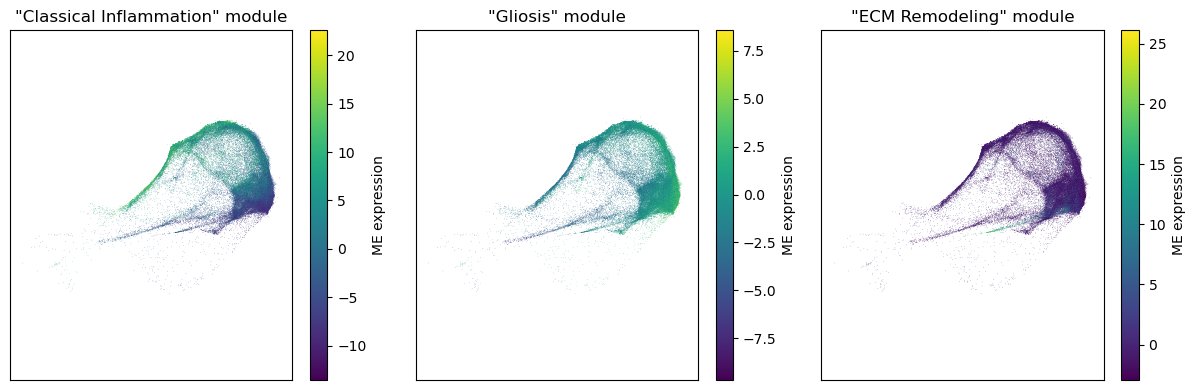

In [21]:
select_modules = ["Classical Inflammation", "Gliosis", "ECM Remodeling",]
# "ECM Remodeling", "Interferon Response"
plot_multiple_umaps(merged_df, select_modules)

In [22]:
# tau_scores = {}

# for module in select_modules:
#     tau_df = merged_df[["class", module]].copy()
#     tau_df[module] = tau_df[module] - tau_df[module].min() + 1e-6  # Shift the eigengene values to ensure non-negativity

#     # Compute average eigengene per cell class
#     avg_expression = tau_df.groupby('class', observed=False)[module].mean()

#     # Normalize by the maximum average expression
#     max_expr = avg_expression.max()
#     normalized_expr = avg_expression / max_expr

#     # Compute tau score
#     tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
#     tau_scores[module] = tau

# # Print Tau scores for all modules
# for module, score in tau_scores.items():
#     print(f"Tau specificity score for {module} module: {score:.3f}")

In [28]:
adata_DEG.obs.head()

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,batch,leiden_res_0.50
cell_label,,,,,,,,,,,,,,,,,,,,,
TGGATCAGTAACACCT-478_A02-0,TGGATCAGTAACACCT,478_A02,L8TX_210107_02_H11,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-556943,Ai14(RCL-tdT)/wt,...,5312 Microglia NN_1,#666666,#825f45,#CC1F4E,#62CC3D,#651FCC,28,#CC0026,0,0
TCACTCGCAAGTTCGT-215_C01-0,TCACTCGCAAGTTCGT,215_C01,L8TX_200206_01_D03,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507771,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,5312 Microglia NN_1,#666666,#825f45,#CC1F4E,#62CC3D,#651FCC,28,#CC0026,0,2
GAGTGAGTCCTTATCA-472_B05-0,GAGTGAGTCCTTATCA,472_B05,L8TX_201217_01_H07,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-557213,Ai14(RCL-tdT)/wt,...,5312 Microglia NN_1,#666666,#825f45,#CC1F4E,#62CC3D,#651FCC,28,#CC0026,0,0
CACGGGTTCATTTCCA-216_D01-0,CACGGGTTCATTTCCA,216_D01,L8TX_200206_01_A04,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-507773,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,...,5312 Microglia NN_1,#666666,#825f45,#CC1F4E,#62CC3D,#651FCC,28,#CC0026,0,3
TTTCACATCCGCACTT-171_C01-0,TTTCACATCCGCACTT,171_C01,L8TX_191029_01_E08,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Snap25-IRES2-Cre;Ai14-493659,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,5312 Microglia NN_1,#666666,#825f45,#CC1F4E,#62CC3D,#651FCC,28,#CC0026,0,0


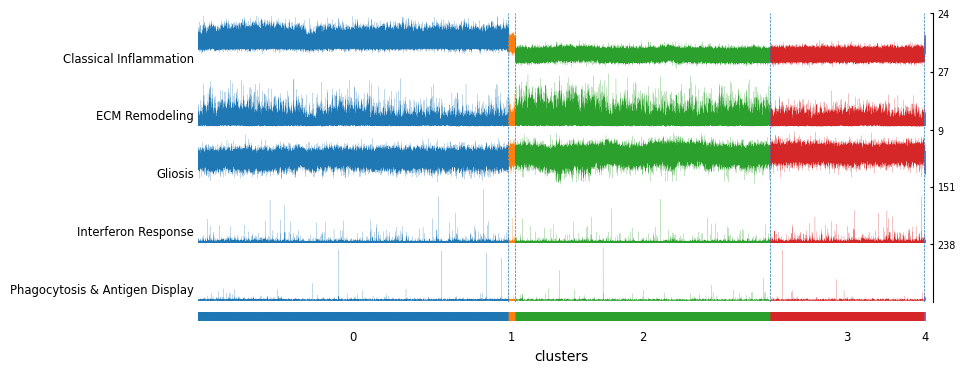

In [ ]:
# Add all module eigengenes to AnnData and class labels
modules = eigengenes.columns.tolist()
adata_tracks = sc.AnnData(merged_df[modules])
adata_tracks.obs["clusters"] = adata_DEG.obs["leiden_res_0.50"].astype("category")  # Ensure categorical dtype

# Plot tracksplot of module eigengenes across cell classes
sc.pl.tracksplot(
    adata_tracks,
    var_names=modules,
    groupby="clusters",
    figsize=(10, 4),
    dendrogram=False,
    title="Tracksplot of Module Eigengenes Across Cell Classes",
    # cmap="viridis"
)

In [35]:
n_top_genes_per_module = 10  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    if module_name == "grey":
        continue  # Skip the grey module

    
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_MG-M1,kME_grey,kME_MG-M2,kME_MG-M3,kME_MG-M4,kME_MG-M5
0,ENSMUSG00000038418,MG-M1,turquoise,0.772310,0.063035,0.054245,-0.034519,-0.026892,-0.348611
1,ENSMUSG00000021025,MG-M1,turquoise,0.747866,0.002690,0.069530,-0.046087,-0.013457,-0.313880
2,ENSMUSG00000035356,MG-M1,turquoise,0.732437,0.023227,0.095436,-0.033552,-0.004144,-0.288948
3,ENSMUSG00000053560,MG-M1,turquoise,0.731475,0.056730,0.067427,-0.052954,-0.023013,-0.355106
4,ENSMUSG00000021250,MG-M1,turquoise,0.667237,0.107338,0.060209,-0.019332,-0.024286,-0.335335


In [31]:
gene_names_df = adata.var.copy()

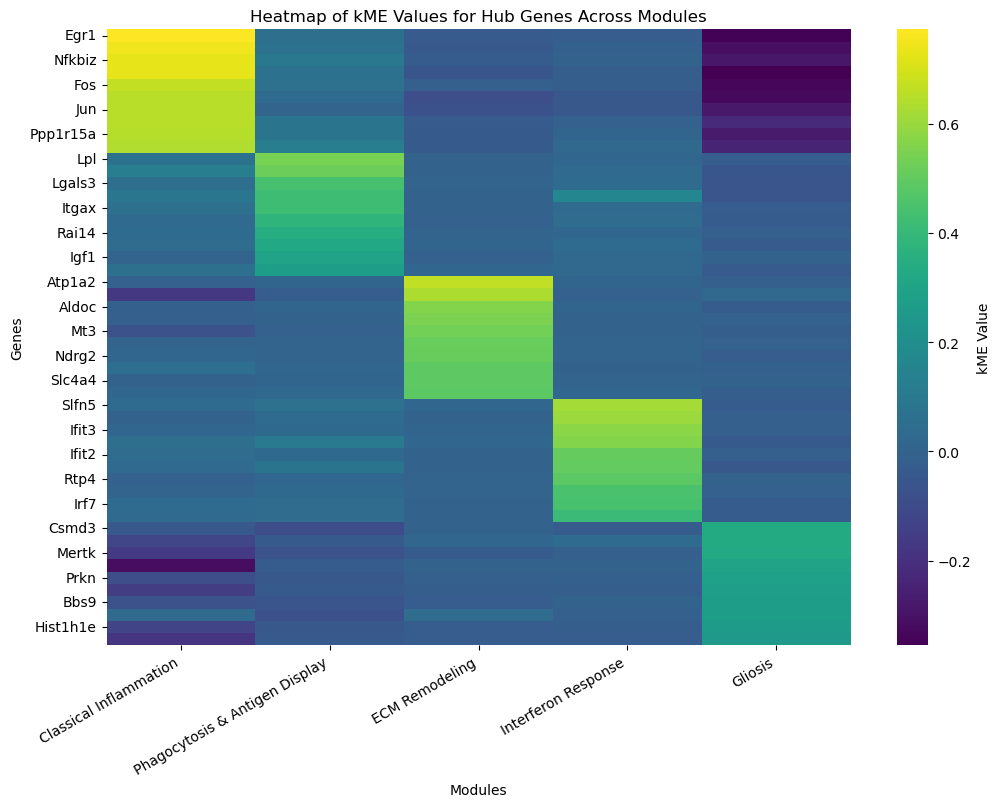

In [37]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [
    module_names.get(col.replace("kME_", ""), col.replace("kME_", ""))
    for col in heatmap_data.columns
]

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xticks(rotation=30, ha="right")
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Hub Genes Across Modules")
plt.savefig("figures/heatmap_kME_ABCA_MG.svg")
plt.show()

### Overlap with DEGs

In [9]:
# Selecting the leiden key
leiden_key = "leiden_res_0.50"
rank_genes_key = "rank_genes_groups"

# Save the dataframe to a CSV file
output_path = base_path / "DEG/" / f"WMB-10Xv3-{select_region}-DEG-{leiden_key}.csv"
deg_results = pd.read_csv(output_path)
deg_results.head()

,0,1,2,3,4
0,Egr1,Gm34455,Uty,Xist,Ccl4
1,Nfkbia,Polg2,Nrgn,Hist1h2bc,Csf1
2,Nfkbiz,Gadd45g,Camk2n1,Csmd3,Ccl3
3,Ier2,Chka,Ddx3y,Hist1h1d,Slc15a3
4,Tnfaip3,Milr1,Camk2a,Hist1h1c,Myo1e


In [14]:
del module_gene_dict["grey"]

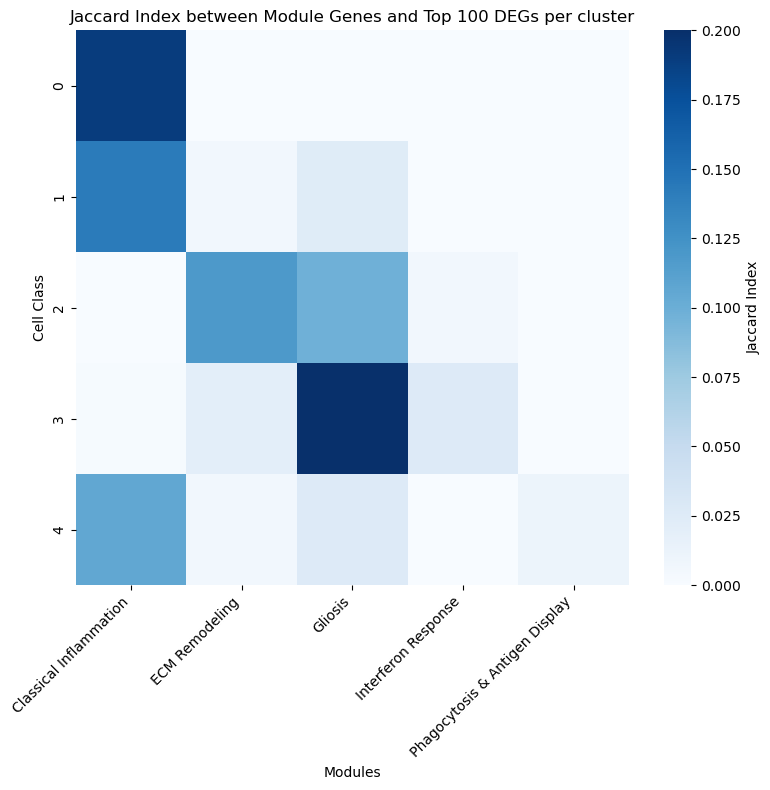

In [17]:
# 1. Get top 100 DEGs per class from deg_results (each column is a class, values are gene names)
top_n_deg = 100
deg_sets = {
    cls: set(deg_results[cls].dropna().head(top_n_deg))
    for cls in deg_results.columns
}

# Get unique modules and their gene lists
module_gene_dict = modules_df_renamed.groupby("module")["gene_name"].apply(list).to_dict()
del module_gene_dict["grey"]

# 2. Build module gene sets (using gene symbols)
gene_symbol_map = adata.var["gene_symbol"].to_dict()
module_gene_sets = {
    mod: set([gene_symbol_map.get(g, g) for g in genes if gene_symbol_map.get(g, g) is not None])
    for mod, genes in module_gene_dict.items()
}

# 3. Compute Jaccard index matrix
import pandas as pd
jaccard_matrix = pd.DataFrame(
    index=module_gene_sets.keys(),
    columns=deg_sets.keys(),
    dtype=float
)

for mod, mod_genes in module_gene_sets.items():
    for cls, deg_genes in deg_sets.items():
        intersection = len(mod_genes & deg_genes)
        union = len(mod_genes | deg_genes)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_matrix.loc[mod, cls] = jaccard

# 4. Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(
    jaccard_matrix.astype(float).T,
    annot=False,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Jaccard Index"}
)
plt.title("Jaccard Index between Module Genes and Top 100 DEGs per cluster")
plt.xlabel("Modules")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Cell Class")
plt.tight_layout()
# plt.savefig("figures/heatmap_jaccard_index_ABCA_MG.svg")
plt.show()

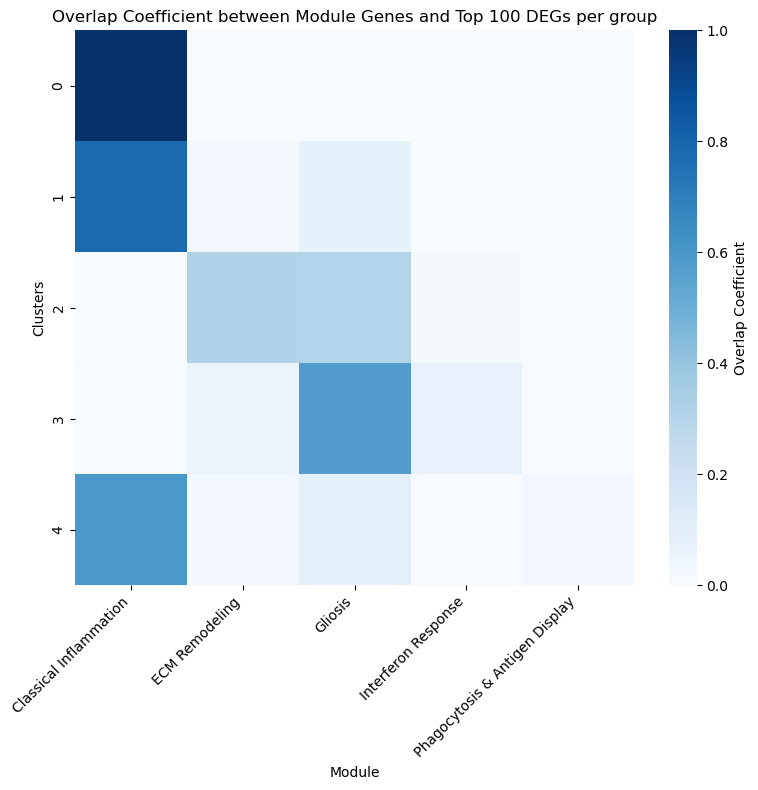

In [20]:
# 1. Get top 100 DEGs per class from deg_results (each column is a class, values are gene names)
top_n_deg = 100
deg_sets = {
    cls: set(deg_results[cls].dropna().head(top_n_deg))
    for cls in deg_results.columns
}

# 2. Build module gene sets (using gene symbols)
gene_symbol_map = adata.var["gene_symbol"].to_dict()
module_gene_sets = {
    mod: set([gene_symbol_map.get(g, g) for g in genes if gene_symbol_map.get(g, g) is not None])
    for mod, genes in module_gene_dict.items()
}

# 3. Compute Overlap Coefficient matrix (Szymkiewicz–Simpson)
import pandas as pd
import numpy as np

overlap_matrix = pd.DataFrame(
    index=module_gene_sets.keys(),
    columns=deg_sets.keys(),
    dtype=float
)

for mod, mod_genes in module_gene_sets.items():
    for cls, deg_genes in deg_sets.items():
        inter = len(mod_genes & deg_genes)
        denom = min(len(mod_genes), len(deg_genes))
        overlap = inter / denom if denom > 0 else np.nan  # avoid divide-by-zero
        overlap_matrix.loc[mod, cls] = overlap

# 4. Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(
    overlap_matrix.astype(float).T,
    annot=False,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Overlap Coefficient"}
)
plt.title(f"Overlap Coefficient between Module Genes and Top {top_n_deg} DEGs per group")
plt.xlabel("Module")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Clusters")
plt.tight_layout()
# plt.savefig("figures/heatmap_overlap_coefficient_Super_CNA.svg")
plt.show()
